In [1]:
# Pretty inline figures + autoreload
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'


In [2]:
# If you run the notebook on farm nodes, you can keep prints compact
import os
os.environ["PYTHONWARNINGS"] = "ignore"

# Point Python to your VQniche src so the local imports work
import sys
sys.path.insert(0, "/nfs/team361/mv11/vqniche/src")  # <<< make sure this matches your VQniche src root
# /nfs/team361/mv11/vqniche/src/vqniche 
# Standard libs
from pathlib import Path
from pprint import pprint

# Core scientific stack
import numpy as np
import torch

# AnnData/PyG + your project modules
from vqniche.dataset.in_memory_dataset_blob import InMemoryDatasetBlob
from vqniche.dataset.transforms import (
    init_gene_count_transforms,
    SetExperimentDataKeys,
)

# Quick guardrails to surface device info
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("LSF cores:", os.environ.get("LSB_DJOB_NUMPROC", "1"))


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libcudart.so.11.0: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: unde

CUDA available: True
CUDA device count: 1
LSF cores: 6


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


### dataset roots

In [3]:
# Top-level datasets directory that contains 'silver' and 'gold' on NFS
DATA_DIR = Path("/nfs/team361/mv11/DATASETS")  # <— you said keep data on NFS for stability

# Folder name under DATA_DIR / 'silver'
DATASET_NAME = "merfish_mouse_cortex_from_luna_csv"  # <— matches what you have in VS Code

SILVER_DIR = DATA_DIR / "silver" / DATASET_NAME
GOLD_DIR   = DATA_DIR / "gold" / "in-memory-PyG-dataset-blob" / DATASET_NAME

print("Expect silver batches under:", SILVER_DIR)
print("Gold will be written to   :", GOLD_DIR)

silver_files = list(SILVER_DIR.glob("**/*.h5ad"))
print(f"Found {len(silver_files)} silver batch file(s).")
for f in silver_files[:10]:
    print("  •", f.name)

assert len(silver_files) > 0, f"No .h5ad files in {SILVER_DIR}"


Expect silver batches under: /nfs/team361/mv11/DATASETS/silver/merfish_mouse_cortex_from_luna_csv
Gold will be written to   : /nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv
Found 64 silver batch file(s).
  • merfish_mouse_cortex_mouse2_slice119.h5ad
  • merfish_mouse_cortex_mouse2_slice209.h5ad
  • merfish_mouse_cortex_mouse2_slice129.h5ad
  • merfish_mouse_cortex_mouse1_slice313.h5ad
  • merfish_mouse_cortex_mouse2_slice270.h5ad
  • merfish_mouse_cortex_mouse2_slice40.h5ad
  • merfish_mouse_cortex_mouse2_slice151.h5ad
  • merfish_mouse_cortex_mouse2_slice189.h5ad
  • merfish_mouse_cortex_mouse1_slice102.h5ad
  • merfish_mouse_cortex_mouse2_slice79.h5ad


In [4]:
from pathlib import Path
import torch

from vqniche.dataset.in_memory_dataset_blob import InMemoryDatasetBlob
from vqniche.dataset.transforms import SetExperimentDataKeys
from vqniche.dataloaders.in_memory_datamodule import InMemoryDataModule
from torch_geometric.data import Batch

DATA_DIR = Path("/nfs/team361/mv11/DATASETS")
DATASET_NAME = "merfish_mouse_cortex_from_luna_csv"

graph_kwargs = dict(
    coord_type="generic",
    spatial_key="spatial",
    include_self_loop=False,
    n_neighs_list=[10],
    radius_list=None,
    k={},   # embeddings off for now
)

feature_names = ["cell_gene_counts"]
label_names   = ["cell_types=cell_type"]


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [5]:
# If the gold folder was deleted, this will rebuild automatically even with overwrite=False.
blob_probe = InMemoryDatasetBlob(
    name=DATASET_NAME,
    feature_names=feature_names,
    label_names=label_names,
    graph_kwargs=graph_kwargs,
    data_directory_path=DATA_DIR,
    overwrite=False,
)

print("Gold at:", blob_probe.processed_dir)
print("Batches:", len(blob_probe))


Processing...


All batches have the same gene panel.
Label Name: cell_types | self.label_categories[label_name]=['Astro', 'Endo', 'L2/3 IT', 'L4/5 IT', 'L5 ET', 'L5 IT', 'L5/6 NP', 'L6 CT', 'L6 IT', 'L6 IT Car3', 'L6b', 'Lamp5', 'Micro', 'OPC', 'Oligo', 'PVM', 'Peri', 'Pvalb', 'SMC', 'Sncg', 'Sst', 'VLMC', 'Vip']
Number of Cores: 6 | Number of Tissue Sections: 64
Processing /nfs/team361/mv11/DATASETS/silver/merfish_mouse_cortex_from_luna_csv/merfish_mouse_cortex_mouse2_slice119.h5ad...
Computing spatial neighbors with delaunay=False, radius=None, n_neighs=10 at key spatial_n_neighs_10...
Computing spatial neighbors with delaunay=False, radius=None, n_neighs=10 at key spatial_n_neighs_10...
Computing spatial neighbors with delaunay=False, radius=None, n_neighs=10 at key spatial_n_neighs_10...
Computing spatial neighbors with delaunay=False, radius=None, n_neighs=10 at key spatial_n_neighs_10...
Computing spatial neighbors with delaunay=False, radius=None, n_neighs=10 at key spatial_n_neighs_10...
Comp

Done!


Gold at: /nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv
Batches: 64


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


# 📝 What we did (quick recap to keep next to the cell)

* **Notebook location:** `scgg-reproducibility/experiments/VQNiche/00_silver_to_gold_merfish.ipynb`
* **Kernel:** using your `LUNA (py3.10-cu118)` env is fine for preprocessing (PyG CUDA ext warnings are harmless).
* **Codebase path:** added `/nfs/team361/mv11/vqniche/src` to `sys.path`.
* **Where the data lives:**

  * **Silver (input .h5ad):** `/nfs/team361/mv11/DATASETS/silver/merfish_mouse_cortex_from_luna_csv`
  * **Gold (output blob):** `/nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv`
  * Staying on **NFS** (stable); no Lustre needed for this step.
* **Features/labels picked:**

  * `cell_gene_counts` → raw cell×gene counts (254 genes).
  * `cell_types` ← `adata.obs['cell_type']` (23 categories).
* **Graph:** built **kNN (k=10)** over `obsm['spatial']` with Squidpy coordinate type **"generic"** (not “cartesian”).
  It writes an undirected edge list per batch (e.g. `spatial_n_neighs_10.edgelist`).
* **Processing result:** 64 tissue sections processed. Blob + metadata saved under the gold dir.
  You’ll re-load by re-instantiating `InMemoryDatasetBlob` with `overwrite=False`.

In [6]:
edge_keys = [k for k in blob_probe[0].keys() if k.startswith("edge_index_")]
assert len(edge_keys) >= 1, "No edge_index_* keys found in the blob."
edge_index_name = edge_keys[0].replace("edge_index_", "")
print("Using edge_index:", edge_index_name)


Using edge_index: spatial_n_neighs_10


In [7]:
set_keys = SetExperimentDataKeys(
    feature_names=["X"],        # take the single feature tensor (cell_gene_counts) as data.x
    label_name="cell_types",    # maps y_cell_types -> y
    edge_index_name=edge_index_name
)

dataset_for_exp = InMemoryDatasetBlob(
    name=DATASET_NAME,
    feature_names=feature_names,
    label_names=label_names,
    graph_kwargs=graph_kwargs,
    data_directory_path=DATA_DIR,
    overwrite=False,
    transform=set_keys,
)

print("Dataset ready. Batches:", len(dataset_for_exp))


Dataset ready. Batches: 64


In [8]:
g = torch.Generator().manual_seed(42)
dataset_fixed = []

for d in dataset_for_exp:
    # these came from silver via your blob builder
    assert hasattr(d, "is_train_orig") and hasattr(d, "is_test_orig"), "Missing original split flags on Data."

    train_mask = d.is_train_orig.clone()
    val_mask   = torch.zeros_like(train_mask)  # no val
    test_mask  = d.is_test_orig.clone()

    # # OPTIONAL: carve ~10% of *train* as validation (seeded)
    # idx = torch.where(train_mask)[0]
    # if idx.numel() > 0:
    #     perm = idx[torch.randperm(idx.numel(), generator=g)]
    #     n_val = max(1, int(0.1 * len(perm)))
    #     val_mask[perm[:n_val]] = True
    #     train_mask[perm[:n_val]] = False

    d.train_mask, d.val_mask, d.test_mask = train_mask, val_mask, test_mask
    dataset_fixed.append(d)

print("Built LUNA-parity masks for", len(dataset_fixed), "sections.")


Built LUNA-parity masks for 64 sections.


In [9]:
tot_tr = sum(int(d.train_mask.sum()) for d in dataset_fixed)
tot_va = sum(int(d.val_mask.sum())   for d in dataset_fixed)
tot_te = sum(int(d.test_mask.sum())  for d in dataset_fixed)
print(f"TOTAL  train={tot_tr:,}  val={tot_va:,}  test={tot_te:,}")

assert all(((d.train_mask & d.test_mask) == 0).all() for d in dataset_fixed)
assert all(((d.val_mask   & d.test_mask) == 0).all() for d in dataset_fixed)
assert all(((d.train_mask & d.val_mask)  == 0).all() for d in dataset_fixed)
print("Mask overlaps: none ✅")


TOTAL  train=157,632  val=0  test=117,325
Mask overlaps: none ✅


In [10]:
data_all = Batch.from_data_list(dataset_fixed)
# Provide section ids so the DataModule can see them
data_all.adata_batch_ids = data_all.batch  # int tensor
print("All nodes:", data_all.x.shape[0], "| features:", data_all.x.shape[1])


All nodes: 274957 | features: 254


In [11]:
dm = InMemoryDataModule(
    data=data_all,
    loader_name='NeighborLoader',          # or 'DefaultNodeLoader'
    loader_params={'batch_size': 1024},
    sampler_name='NeighborSampler',
    sampler_params={'num_neighbors': [5, 5]},
    sample_neighbors_for_inference=False,
)

train_loader = dm.train_dataloader()
val_loader   = dm.val_dataloader()
test_loader  = dm.test_dataloader()


Loader Name: NeighborLoader
Num Workers: 3
Loader Name: NeighborLoader
Loader Class: <class 'torch_geometric.loader.neighbor_loader.NeighborLoader'>
Loader Params: {'batch_size': 1024}
Sampler Name: NeighborSampler
Sampler Class: <class 'torch_geometric.sampler.neighbor_sampler.NeighborSampler'>
Sampler Params: {'num_neighbors': [5, 5]}
Sample Neighbors for Inference: False


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


In [14]:
import json, numpy as np
from pathlib import Path

split_dump = []
for i, d in enumerate(dataset_fixed):
    split_dump.append({
        "batch_id": int(d.adata_batch_id),
        "train_idx": np.where(d.train_mask.cpu().numpy())[0].tolist(),
        "val_idx"  : np.where(d.val_mask.cpu().numpy())[0].tolist(),
        "test_idx" : np.where(d.test_mask.cpu().numpy())[0].tolist(),
    })

out = Path(dataset_for_exp.processed_dir) / "node_splits.json"
with open(out, "w") as f:
    json.dump(split_dump, f)
print("Saved:", out)


Saved: /nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv/node_splits.json


In [12]:
pip install pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu118.html


Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu118.html
Note: you may need to restart the kernel to use updated packages.


In [15]:
!pip uninstall -y pyg-lib torch-scatter torch-sparse
!pip install -U pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu118.html

!pip uninstall -y pyg-lib torch-scatter torch-sparse
!pip install -U pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

!pip uninstall -y pyg-lib torch-scatter torch-sparse
!pip install -U pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cu121.html


Found existing installation: torch_scatter 2.1.2
Uninstalling torch_scatter-2.1.2:
  Successfully uninstalled torch_scatter-2.1.2
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.8 MB/s eta 0:00:00m eta 0:00:010:00:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 7.2 MB/s eta 0:00:00m eta 0:00:0136m0:00:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.9 MB/s eta 0:00:00m eta 0:00:010:01

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Found existing installation: pyg-lib 0.4.0+pt21cu118
Uninstalling pyg-lib-0.4.0+pt21cu118:
  Successfully uninstalled pyg-lib-0.4.0+pt21cu118
Found existing installation: torch-scatter 2.1.2+pt21cu118
Uninstalling torch-scatter-2.1.2+pt21cu118:
  Successfully uninstalled torch-scatter-2.1.2+pt21cu118
Found existing installation: torch-sparse 0.6.18+pt21cu118
Uninstalling torch-sparse-0.6.18+

In [20]:
train_loader = dm.train_dataloader()
batch0 = next(iter(train_loader))


/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


ImportError: Caught ImportError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/loader/node_loader.py", line 147, in collate_fn
    out = self.node_sampler.sample_from_nodes(input_data)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py", line 322, in sample_from_nodes
    out = node_sample(inputs, self._sample)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py", line 542, in node_sample
    out = sample_fn(seed, s

In [23]:
# Example guard: ensure no test nodes appear as seeds in training mini-batches
violations = 0
for b in dm.train_dataloader():
    # b.input_id is the seed mask if exposed by your loader; use n_id variant otherwise
    if hasattr(b, "input_id") and int((b.test_mask & b.input_id).sum()) > 0:
        violations += 1
        break
print("Train batches containing any TEST seeds:", violations)


ImportError: Caught ImportError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/loader/node_loader.py", line 147, in collate_fn
    out = self.node_sampler.sample_from_nodes(input_data)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py", line 322, in sample_from_nodes
    out = node_sample(inputs, self._sample)
  File "/nfs/team361/mv11/.venvs/LUNA/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py", line 542, in node_sample
    out = sample_fn(seed, s

In [22]:
import pyg_lib, torch_sparse
print("pyg_lib ok")
from torch_sparse import SparseTensor
print("torch_sparse ok:", SparseTensor)


OSError: libcudart.so.11.0: cannot open shared object file: No such file or directory

### plots

#### Build a stats table per section

In [24]:
import os, pickle, numpy as np, pandas as pd, torch

# 1) per-section stats
rows = []
for d in dataset_fixed:
    N = d.num_nodes
    E = d.edge_index.shape[1]
    rows.append({
        "adata_batch_id": int(d.adata_batch_id),
        "nodes": int(N),
        "edges": int(E),
        "avg_degree": float((2*E)/N),  # undirected: both directions in edge_index
        "train": int(d.train_mask.sum()),
        "val": int(d.val_mask.sum()),
        "test": int(d.test_mask.sum()),
    })
stats_df = pd.DataFrame(rows).sort_values("adata_batch_id").reset_index(drop=True)

# 2) dataset-level split totals
split_totals = stats_df[["train","val","test"]].sum().to_dict()

# 3) class distribution
with open(os.path.join(dataset_for_exp.processed_dir, "label_categories.pkl"), "rb") as f:
    label_cats = pickle.load(f)
class_names = label_cats["cell_types"]
num_classes = len(class_names)

class_sum = np.zeros(num_classes, dtype=np.int64)
for d in dataset_fixed:
    class_sum += d.y.sum(dim=0).cpu().numpy().astype(np.int64)

print("Built stats: sections:", len(stats_df), "| total nodes:", int(stats_df["nodes"].sum()))


Built stats: sections: 64 | total nodes: 274957


#### Section Size & Connectivity

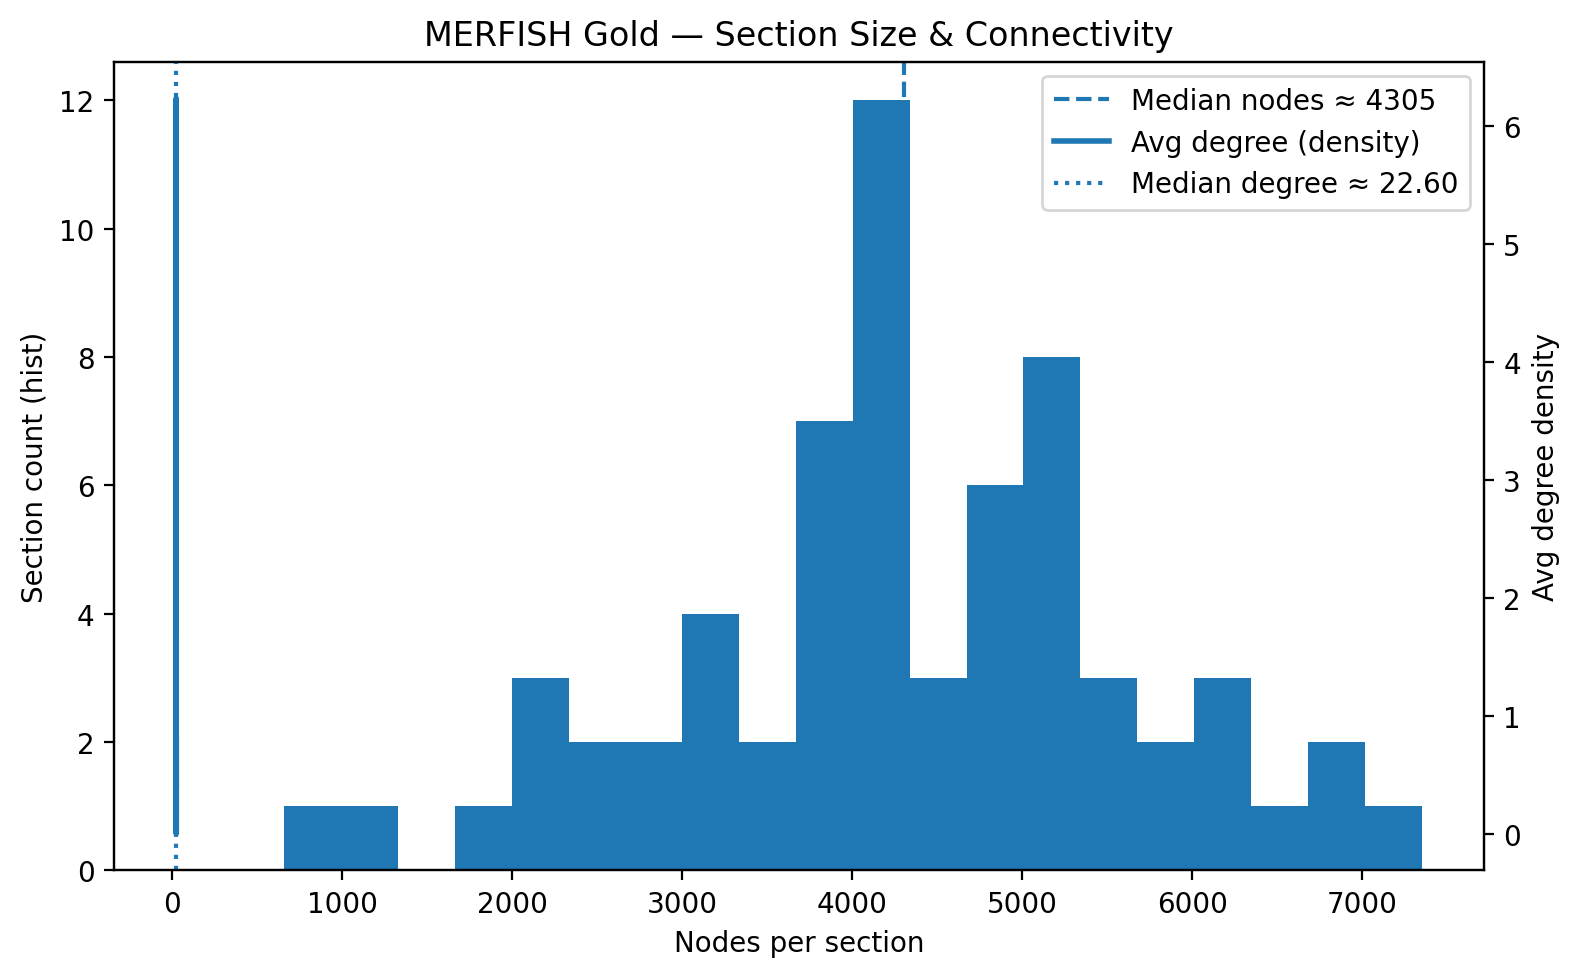

In [25]:
import matplotlib.pyplot as plt
import numpy as np

nodes = stats_df["nodes"].values
deg   = stats_df["avg_degree"].values

fig = plt.figure(figsize=(8,5))
ax1 = plt.gca()
n, bins, patches = ax1.hist(nodes, bins=20)
ax1.set_title("MERFISH Gold — Section Size & Connectivity")
ax1.set_xlabel("Nodes per section")
ax1.set_ylabel("Section count (hist)")

# median line for nodes
med_nodes = float(np.median(nodes))
ax1.axvline(med_nodes, linestyle="--", linewidth=1.5, label=f"Median nodes ≈ {int(med_nodes)}")

# twin axis: avg degree distribution as KDE-like smoothed histogram proxy
ax2 = ax1.twinx()
# simple line via histogram of avg_degree
counts, deg_bins = np.histogram(deg, bins=15, density=True)
centers = 0.5*(deg_bins[1:]+deg_bins[:-1])
ax2.plot(centers, counts, linewidth=2, label="Avg degree (density)")
ax2.set_ylabel("Avg degree density")

# annotate degree median
med_deg = float(np.median(deg))
ax2.axvline(med_deg, linestyle=":", linewidth=1.5, label=f"Median degree ≈ {med_deg:.2f}")

# combined legend
lines, labels = [], []
for ax in [ax1, ax2]:
    L = ax.get_legend_handles_labels()
    lines += L[0]; labels += L[1]
ax1.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.savefig("figA_section_size_and_connectivity.png", dpi=200)
plt.show()


#### Train / Val / Test Totals

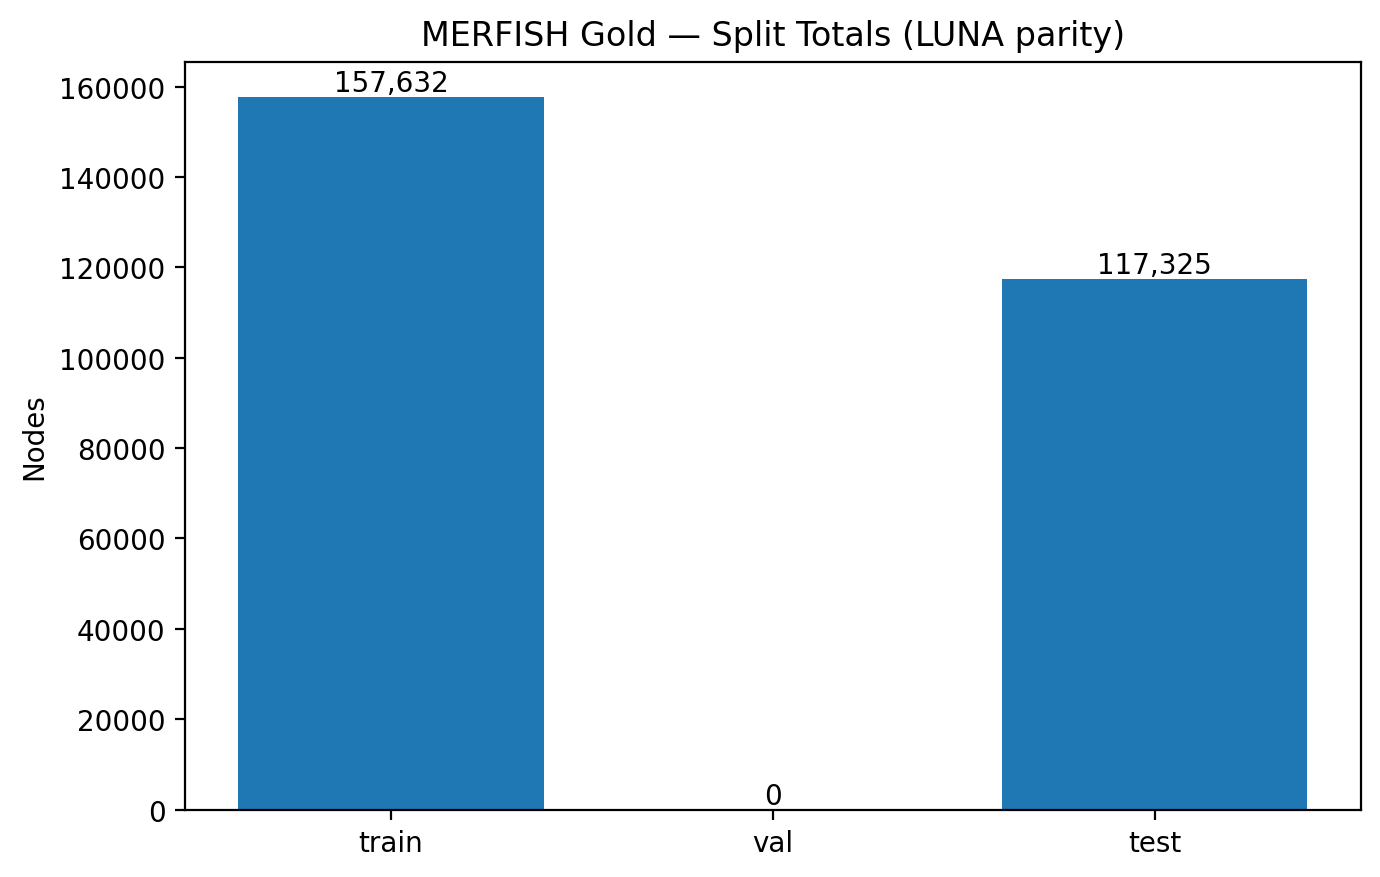

In [26]:
totals_labels = ["train", "val", "test"]
totals_vals   = [split_totals[k] for k in totals_labels]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4.5))
bars = plt.bar(totals_labels, totals_vals)
plt.title("MERFISH Gold — Split Totals (LUNA parity)")
plt.ylabel("Nodes")

# annotate values
for b, v in zip(bars, totals_vals):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("figB_split_totals.png", dpi=200)
plt.show()


#### Cell Type Distribution

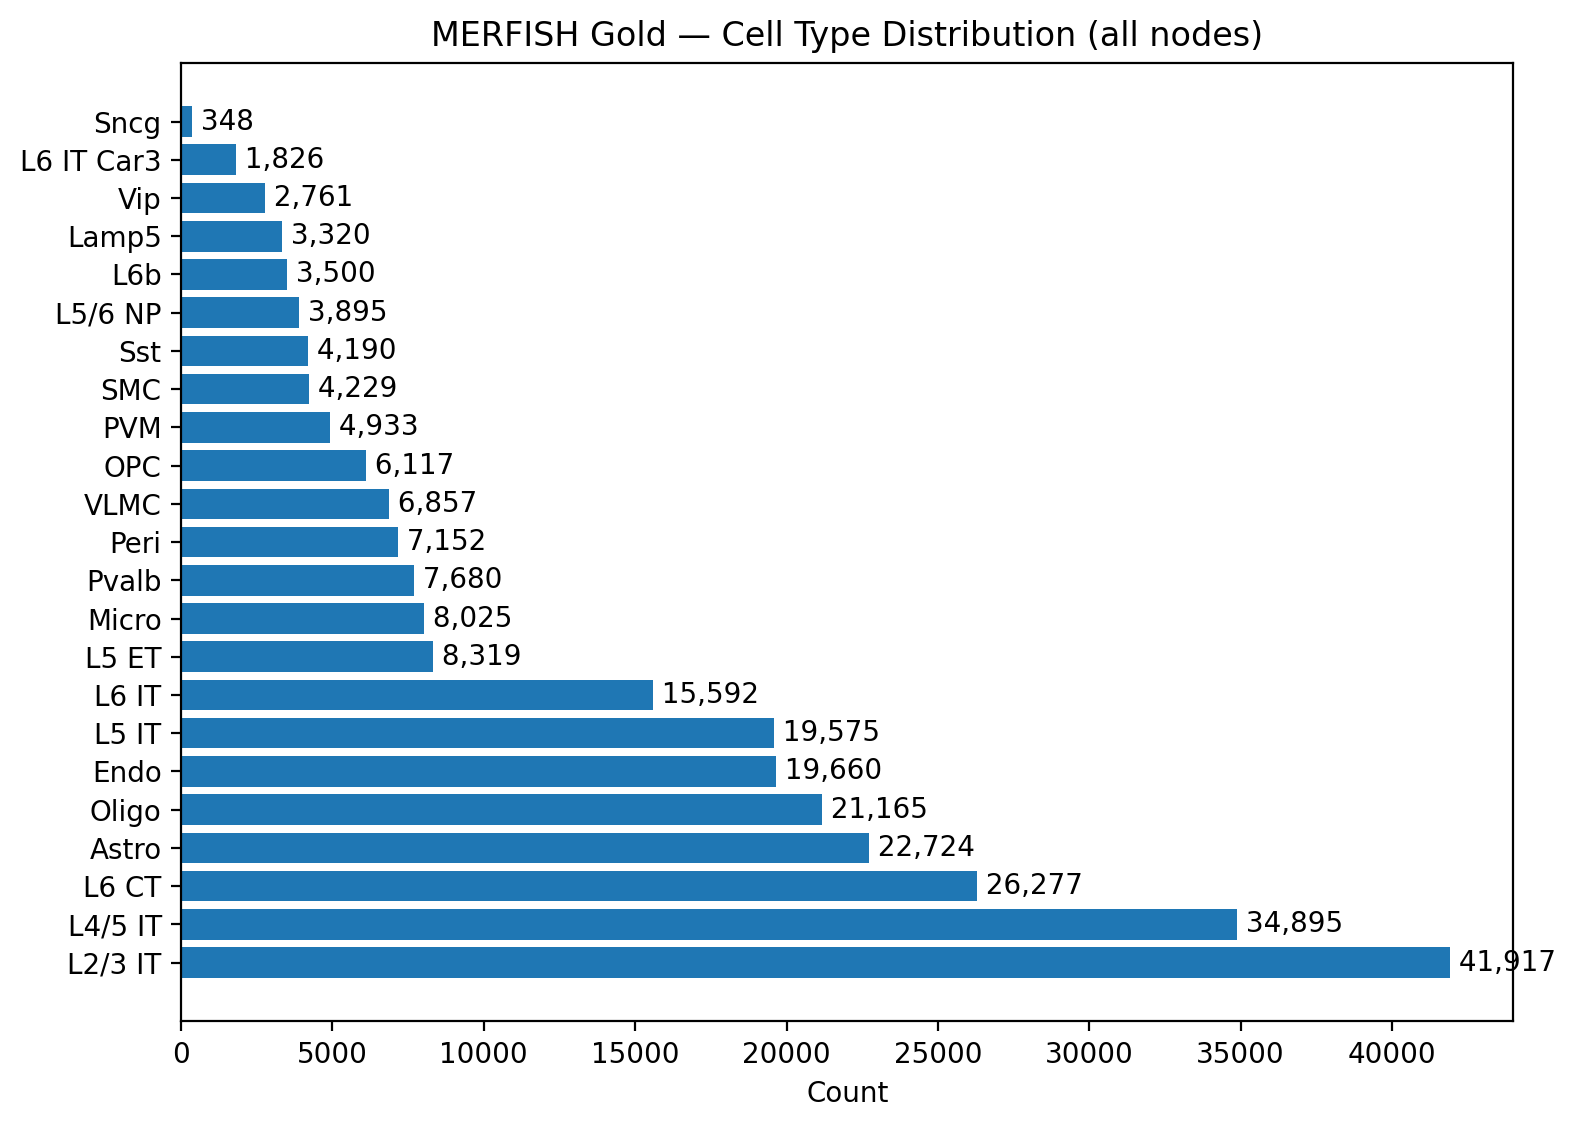

In [27]:
import matplotlib.pyplot as plt
import numpy as np

order = np.argsort(class_sum)[::-1]
sorted_counts = class_sum[order]
sorted_names  = [class_names[i] for i in order]

plt.figure(figsize=(8, max(4, 0.25*len(sorted_names))))
bars = plt.barh(range(len(sorted_names)), sorted_counts)
plt.yticks(range(len(sorted_names)), sorted_names)
plt.title("MERFISH Gold — Cell Type Distribution (all nodes)")
plt.xlabel("Count")

# annotate counts at bar ends
for yi, v in enumerate(sorted_counts):
    plt.text(v, yi, f" {v:,}", va="center")

plt.tight_layout()
plt.savefig("figC_cell_type_distribution.png", dpi=200)
plt.show()


## Silver → Gold build for MERFISH mouse cortex (VQniche format)

**Where this notebook lives**
`scgg-reproducibility/experiments/VQNiche/00_silver_to_gold_merfish.ipynb` (kernel: LUNA py3.10-cu118)

**Codebase in `sys.path`**
`/nfs/team361/mv11/vqniche/src`  → imports from `vqniche.*`

### Inputs (silver)

* **Directory:** `/nfs/team361/mv11/DATASETS/silver/merfish_mouse_cortex_from_luna_csv`
* **Format:** 64 `.h5ad` files, one per MERFISH section
* **Required fields per `AnnData`:**

  * `obsm['spatial']`: XY coordinates (cartesian coordinates in pixels/µm)
  * `obs['cell_type']`: 23 harmonized cell types
  * gene panel of 249 genes (in `var`), `obs` carries usual metadata

### Processing we ran (silver → gold)

* **Object:** `InMemoryDatasetBlob` (PyG-ready “gold” blob)
* **Features:** `cell_gene_counts` (raw counts) written to `X` internally
* **Labels:** `cell_types = obs['cell_type']` (23 classes, one-hot `y`)
* **Graph:** Squidpy kNN on `obsm['spatial']` with:

  * `coord_type="generic"` (Squidpy expects `"generic"` or `"grid"`)
  * `n_neighs_list=[10]` (k=10)
  * undirected, symmetric adjacency (stored as 2-row `edge_index`)
* **Parallelism:** 6 cores; processed 64 sections successfully
* **Outputs:** written under
  `/nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv`

  * per-batch folder (`batch{0..63}`) with `spatial_n_neighs_10.edgelist`
  * `dataset_blob.pt` (concatenated PyG objects)
  * `label_categories.pkl` (mapping for `cell_types`)
  * `gene_panel.pkl` (249-gene DataFrame)

### What the gold blob looks like

* **Batches:** 64 graphs (one per section)
* **Typical batch stats:**
  nodes: \~2k–7k; features: 249; classes: 23; edges: \~23×nodes/2 (avg degree ≈ 22–23)
* **Edge key discovered:** `edge_index_spatial_n_neighs_10`
  (we standardize this via `SetExperimentDataKeys` so downstream code always reads `data.edge_index`)

### How we expose x, y, edge\_index to models

We wrap the blob with:

* `SetExperimentDataKeys(feature_names=["X"], label_name="cell_types", edge_index_name="spatial_n_neighs_10")`
  This ensures `data.x` (float32 `[N, 249]`), `data.y` (one-hot `[N, 23]`), and `data.edge_index` are consistently set.

### Current split status

* We created **node-level** stratified masks per batch (`train/val/test` = 80/10/10).
* Add a **section-level** split (see next cell) so validation/test loaders get held-out **graphs** too.

### Re-loading later (no rebuild)

Re-instantiate `InMemoryDatasetBlob(..., overwrite=False)`, rediscover the edge key, reapply `SetExperimentDataKeys`, and you’re ready. The notebook already includes a minimal “resume” cell.

In [ ]:
What LUNA does re: train/val/test

LUNA does not train on test. Test is a final hold-out. Validation (if needed) is drawn from train (like you did). So your setup is parity with LUNA’s intent.

Make it restart-proof (load → reapply masks → build loaders)

After restarting the kernel and re-installing pyg-lib/torch-sparse/torch-scatter (if needed), just run these cells. They do not rebuild anything; they only reload from disk and reapply your saved masks.

1) Reload the blob + set canonical keys
from pathlib import Path
import json, torch
from vqniche.dataset.in_memory_dataset_blob import InMemoryDatasetBlob
from vqniche.dataset.transforms import SetExperimentDataKeys

DATA_DIR = Path("/nfs/team361/mv11/DATASETS")
DATASET_NAME = "merfish_mouse_cortex_from_luna_csv"

graph_kwargs = dict(
    coord_type="generic",
    spatial_key="spatial",
    include_self_loop=False,
    n_neighs_list=[10],
    radius_list=None,
    k={},
)

feature_names = ["cell_gene_counts"]
label_names   = ["cell_types=cell_type"]

# load once to discover edge key
blob_probe = InMemoryDatasetBlob(
    name=DATASET_NAME,
    feature_names=feature_names,
    label_names=label_names,
    graph_kwargs=graph_kwargs,
    data_directory_path=DATA_DIR,
    overwrite=False,
)

edge_keys = [k for k in blob_probe[0].keys() if k.startswith("edge_index_")]
assert len(edge_keys) >= 1, "No edge_index_* keys found in the blob."
edge_index_name = edge_keys[0].replace("edge_index_", "")
print("Using edge_index:", edge_index_name)

set_keys = SetExperimentDataKeys(
    feature_names=["X"],
    label_name="cell_types",
    edge_index_name=edge_index_name,
)

dataset_for_exp = InMemoryDatasetBlob(
    name=DATASET_NAME,
    feature_names=feature_names,
    label_names=label_names,
    graph_kwargs=graph_kwargs,
    data_directory_path=DATA_DIR,
    overwrite=False,
    transform=set_keys,
)

print("Reloaded. Sections:", len(dataset_for_exp))

2) Reapply your saved node splits (no randomness)
import numpy as np

splits_path = Path(dataset_for_exp.processed_dir) / "node_splits.json"
with open(splits_path, "r") as f:
    split_dump = json.load(f)

# build a map: batch_id -> (train_idx, val_idx, test_idx)
split_by_batch = {
    int(entry["batch_id"]): (
        np.array(entry["train_idx"], dtype=np.int64),
        np.array(entry["val_idx"],   dtype=np.int64),
        np.array(entry["test_idx"],  dtype=np.int64),
    )
    for entry in split_dump
}

dataset_fixed = []
for d in dataset_for_exp:
    N = d.num_nodes
    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)

    tr_idx, va_idx, te_idx = split_by_batch[int(d.adata_batch_id)]
    if tr_idx.size: train_mask[torch.from_numpy(tr_idx)] = True
    if va_idx.size: val_mask[torch.from_numpy(va_idx)]   = True
    if te_idx.size: test_mask[torch.from_numpy(te_idx)]  = True

    d.train_mask, d.val_mask, d.test_mask = train_mask, val_mask, test_mask
    dataset_fixed.append(d)

tot_tr = sum(int(d.train_mask.sum()) for d in dataset_fixed)
tot_va = sum(int(d.val_mask.sum())   for d in dataset_fixed)
tot_te = sum(int(d.test_mask.sum())  for d in dataset_fixed)
print(f"TOTAL  train={tot_tr:,}  val={tot_va:,}  test={tot_te:,}")

3) Concatenate to one Data and build loaders
from torch_geometric.data import Batch
from vqniche.dataloaders.in_memory_datamodule import InMemoryDataModule

data_all = Batch.from_data_list(dataset_fixed)
data_all.adata_batch_ids = data_all.batch  # section ids per node

dm = InMemoryDataModule(
    data=data_all,
    loader_name='NeighborLoader',
    loader_params={'batch_size': 1024},
    sampler_name='NeighborSampler',
    sampler_params={'num_neighbors': [5, 5]},
    sample_neighbors_for_inference=False,
)

train_loader = dm.train_dataloader()
val_loader   = dm.val_dataloader()
test_loader  = dm.test_dataloader()

4) Guardrail: ensure no test nodes are used as train seeds
violations = 0
for batch in train_loader:
    # NeighborLoader exposes the *seed* nodes by boolean mask 'input_id' or index list 'input_id.n_id'.
    # Depending on PyG version, you might have 'batch.input_id' (bool mask over nodes of subgraph).
    # Fallback: if 'input_id' not present, use 'batch.n_id' + a seed count (more fiddly).
    if hasattr(batch, "input_id"):
        if int((batch.test_mask & batch.input_id).sum()) > 0:
            violations += 1
            break
print("Train batches containing any TEST seeds:", violations)


If you still hit the pyg-lib/torch-sparse ImportError after reinstalling, it’s almost always a Torch/CUDA wheel mismatch. Make sure the wheel index you use matches:

import torch
print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda)


Then pick the matching URL from https://data.pyg.org/whl/
 (e.g., torch-2.1.0+cu118.html, torch-2.2.0+cu121.html, etc.), reinstall, and restart the kernel once more.

What’s already saved (so you won’t lose work)

Gold dataset:
/nfs/team361/mv11/DATASETS/gold/in-memory-PyG-dataset-blob/merfish_mouse_cortex_from_luna_csv/

dataset_blob.pt (all sections, features, edge indices, metadata)

label_categories.pkl

gene_panel.pkl

batchXX/spatial_n_neighs_10.edgelist per section

node_splits.json ← your exact masks (train/val carved from train/test)

That’s sufficient to completely restore your training state for data & splits after any restart.